# **Deep Learning Project**
# ***Predicting if a bank customer will exit the bank***

### Importing the libraries

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, regularizers
import wandb

from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from wandb.integration.keras import WandbMetricsLogger

### Login to W&B

In [2]:
wandb.login()

### Importing the dataset

In [ ]:
dataset = pd.read_csv("./../../../data/raw/Bank_Customers.csv")
X = dataset.iloc[:, 3:-1].values
y = dataset.iloc[:, -1].values

In [4]:
#print(X)
#print(y)

## **Data preprocessing**

### Splitting the data into train & test

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Replace missing data

In [6]:
from sklearn.impute import SimpleImputer

numerical_columns = [0, 3, 4, 5, 6, 9]
categorical_columns = [1, 2, 7, 8]

imputer = SimpleImputer(missing_values=np.nan, strategy="median")
imputer.fit(X_train[:, numerical_columns])
X_train[:, numerical_columns] = imputer.transform(X_train[:, numerical_columns])
X_test[:, numerical_columns] = imputer.transform(X_test[:, numerical_columns])

imputer = SimpleImputer(missing_values=np.nan, strategy="most_frequent")
imputer.fit(X_train[:, categorical_columns])
X_train[:, categorical_columns] = imputer.transform(X_train[:, categorical_columns])
X_test[:, categorical_columns] = imputer.transform(X_test[:, categorical_columns])


### One-hot encoding the geography  & gender column

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(
    transformers=[("encoder", OneHotEncoder(sparse_output=False), [1, 2])],
    remainder="passthrough",
)
X_train = np.array(ct.fit_transform(X_train))
X_test = np.array(ct.transform(X_test))

### Feature scaling

In [8]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## **Building the Nerual Network**

In the previous experiment, increasing the network size significantly reduced training loss but caused severe overfitting. The model memorized the training data and failed to generalize.

To address this issue, we introduce regularization techniques to control model complexity and improve generalization.

### Techniques applied
#### 1. Dropout

Dropout randomly disables a fraction of neurons during training.
This prevents the network from relying too heavily on specific connections and forces it to learn more robust patterns.

#### 2. L2 Regularization

L2 regularization penalizes large weights by adding a penalty term to the loss function. This discourages overly complex decision boundaries.

#### 3. Early Stopping

Early stopping monitors validation performance and stops training when performance stops improving.

This prevents the model from continuing to memorize training noise.

### Updating the architecture of the ANN with Regularization

In [ ]:
model = tf.keras.Sequential([
    layers.Dense(128, activation="relu",
                 kernel_regularizer=regularizers.l2(1e-4),
                 input_shape=(X_train.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation="relu",
                 kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(32, activation="relu",
                 kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(1, activation="sigmoid")
])

### Handling Class Imbalance

In [10]:
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

print("Class Weights: ", class_weight_dict)

Class Weights:  {0: np.float64(0.6279434850863422), 1: np.float64(2.4539877300613497)}


## **Training the ANN**


### Compiling the ANN
The model is compiled using:






In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

### Callbacks - Saving checkpoint

In [12]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor='val_loss',
    save_best_only=True,
)

### Early Stopping

In [13]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

### Experiment Tracking with Weights & Biases (W&B)

In [14]:
RUN_NAME = "model_2_exp_3"

wandb.init(
    entity="arminfakhar1384-",
    project="bank_customers_churn",
    name=RUN_NAME,
    config={
        "model_id": 23,
        "architecture": "128-32-relu + sigmoid",
        "epochs": 200,              # max epochs (EarlyStopping will stop earlier)
        "batch_size": 32,
        "learning_rate": 0.001,
        "optimizer": "adam",
        "loss": "binary_crossentropy",
        "class_weight": "balanced"
    }
)

wandb_callback = WandbMetricsLogger()

### Training the ANN on the Training set

In [15]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[checkpoint, early_stop, wandb_callback],
    verbose=1
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.5520 - auc: 0.5931 - loss: 0.8322 - precision: 0.2468 - recall: 0.5887 - val_accuracy: 0.6475 - val_auc: 0.7659 - val_loss: 0.6509 - val_precision: 0.3373 - val_recall: 0.7906
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6642 - auc: 0.7226 - loss: 0.6491 - precision: 0.3273 - recall: 0.6682 - val_accuracy: 0.6988 - val_auc: 0.7996 - val_loss: 0.5891 - val_precision: 0.3746 - val_recall: 0.7563
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.6643 - auc: 0.7467 - loss: 0.6280 - precision: 0.3483 - recall: 0.7083 - val_accuracy: 0.7275 - val_auc: 0.8197 - val_loss: 0.5522 - val_precision: 0.4033 - val_recall: 0.7563
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.6989 - auc: 0.7738 - loss: 0.5902 - precision: 0.3745 - recall: 0.7063 - val_accuracy: 0.7462 - val_auc: 0.8346 - val_loss: 0.5205 - val_precision: 0.4253 - val_recall: 0.7656
Epoch 5/100
200/200 ━━━━━━

### Performance Visualization - Training and Validation Curves

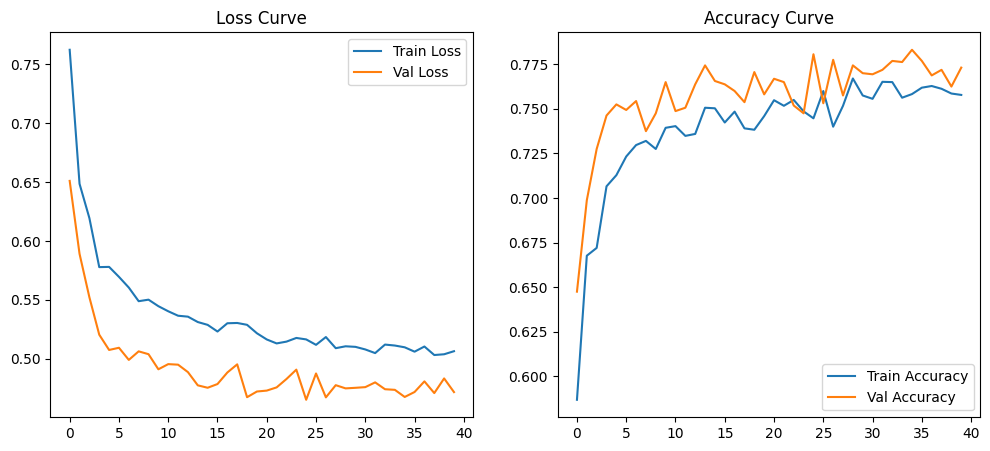

In [16]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss Curve")

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.legend()
plt.title("Accuracy Curve")

plt.show()

### Loss Curve Analysis
Training loss continues to decrease smoothly, which is expected as the model learns.

Validation loss initially decreases but then flattens. This indicates that the model is stabilizing in terms of generalization, with no significant overfitting now. In fact, early stopping likely kicked in before any substantial overfitting could occur.

## **Predicting and evaluating the model**

The trained model is evaluated on the test set.

### Confusion Matrix Analysis

In [17]:
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Confusion Matrix:
 [[1256  337]
 [ 108  299]]


**Performance metrics** 

In [18]:
results = model.evaluate(X_test, y_test, verbose=0)
print("Test Results (loss, acc, precision, recall, auc):\n", results)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, digits=4))

roc_auc = roc_auc_score(y_test, y_pred_prob)
print("ROC-AUC:", roc_auc)

Test Results (loss, acc, precision, recall, auc):
 [0.47537949681282043, 0.7774999737739563, 0.47012579441070557, 0.7346437573432922, 0.8458721041679382]

Classification Report:

              precision    recall  f1-score   support

           0     0.9208    0.7884    0.8495      1593
           1     0.4701    0.7346    0.5733       407

    accuracy                         0.7775      2000
   macro avg     0.6955    0.7615    0.7114      2000
weighted avg     0.8291    0.7775    0.7933      2000

ROC-AUC: 0.845902913699524


### Plotting ROC Curve

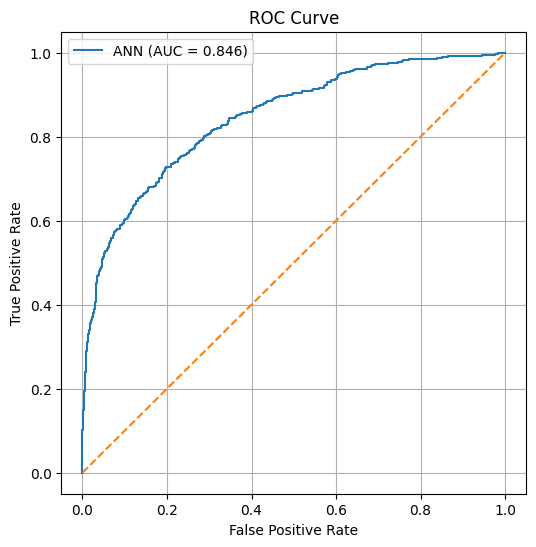

In [19]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ANN (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

## Impact of updating the architecture to prevent overfitting

The introduction of early stopping and regularization clearly had a positive impact. We avoided the severe overfitting we observed in the previous experiment, where the validation loss started increasing, and accuracy became unstable.

However, the model performance still has room for improvement. Despite the improvements in generalization, precision for class 1 (churn) at 0.4701 isn't reasonable.

### Conclusion
After experimenting with a significantly larger neural network and applying regularization techniques to control overfitting, we observe that the overall validation and test performance remains nearly identical to that of the original simpler model.
Although the more complex model achieved much lower training loss and reached very high training accuracy it did not produce meaningful improvements in Test F1-score (especially for the churn class) & Precision–recall balance.

This indicates that the performance limitation was not caused by insufficient model capacity. Therefore, since both models produce similar generalization performance, we will revert to the simpler architecture and focus on alternative improvement strategies.

This experiment demonstrates an important machine learning principle:

**Increasing model complexity does not guarantee better performance.**
